# Titanic EDA Project
## Notebook 01 - Data Loading & First Look

In this notebook we will:
- Load the Titanic dataset
- Explore its basic structure
- Understand what each column means
- Ask initial questions about the data

**Dataset:** Titanic passenger data
**Goal:** Understand the data before touching it

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("All libraries imported successfully!")

In [ ]:
#titanic is built in dataset in seaborn
df = sns.load_dataset('titanic')

#print(df.shape)
#df.head()
#df.dtypes
#df.describe()
#df.isnull().sum()
missing = df.isnull().sum()  #output is a series
missing_percent = (missing/len(df))*100  #output is a series

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent.round(2)
})

missing_df[missing_df['missing_count'] > 0]


In [ ]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(),  # True/False matrix
            yticklabels=False, # don't show row numbers
            cbar=False, # no color bar needed
            cmap='viridis')  # color scheme

plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.savefig('../outputs/01_missing_values.png') # save to outputs folder
plt.show()


In [ ]:
#df['survived'].value_counts()  
#df['survived'].value_counts(normalize=True).round(2)*100 



In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

# Plot 1 - raw counts
sns.countplot(data=df, x='survived', ax=axes[0])
axes[0].set_title('Survival Count')
axes[0].set_xlabel('Survived (0 = No, 1 = Yes)')

# Plot 2 - pie chart for percentages
axes[1].pie(df['survived'].value_counts(),
            labels=['Died', 'Survived'],
            autopct='%1.1f%%',
            colors=['lightcoral', 'lightblue'])
axes[1].set_title('Survival Distribution')
plt.tight_layout()
plt.savefig('../outputs/02_survival_distribution.png') 
plt.show()


In [ ]:
df.groupby('sex')['survived'].mean()*100

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - survival rate by gender
survival_by_gender = df.groupby('sex')['survived'].mean() * 100

sns.barplot(x = survival_by_gender.index,
            y = survival_by_gender.values,
            ax = axes[0],
            hue = survival_by_gender.index,
            palette=['#e74c3c', '#2ecc71'],
            legend=False)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate %')
axes[0].set_xlabel('Gender')

# Plot 2 - count of survived vs died by gender
sns.countplot(data=df, x='sex',hue='survived',ax=axes[1])
axes[1].set_title('Survival Count by Gender')
axes[1].set_xlabel('Gender')

plt.tight_layout()
plt.savefig('../outputs/03_survival_by_gender.png')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - survival rate by class
survival_by_class = df.groupby('pclass')['survived'].mean() * 100
sns.barplot(x=survival_by_class.index,
            y=survival_by_class.values,
            hue=survival_by_class.index,
            palette=['#2ecc71', '#f39c12', '#e74c3c'],
            legend=False,
            ax=axes[0])
axes[0].set_title('Survival Rate by Class')
axes[0].set_ylabel('Survival Rate %')
axes[0].set_xlabel('Passenger Class')

# Plot 2 - gender + class combined using hue
sns.barplot(data=df,
            x='pclass',
            y='survived',
            hue='sex',       
            ax=axes[1],
            errorbar=None)
axes[1].set_title('Survival Rate by Class and Gender')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xlabel('Passenger Class')

plt.tight_layout()
plt.savefig('../outputs/04_survival_by_class.png')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - age distribution
sns.histplot(data = df, x='age', bins=30,ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Plot 2 - age distribution by survival
sns.histplot(data=df, x='age', hue='survived', bins=30, ax=axes[1],multiple='stack')
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.savefig('../outputs/05_age_distribution.png')
plt.show()


In [ ]:
#pd.cut() converts continuous age into categories. It creates a new column.
df['age_group'] = pd.cut(df['age'],bins=[0,12,18,35,60,100],labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
df.groupby('age_group',observed=True)['survived'].mean()*100 #shows only groups that exist in data

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - survival rate by age group
survival_by_age = df.groupby('age_group', observed=True)['survived'].mean() * 100
sns.barplot(x=survival_by_age.index,
            y=survival_by_age.values,
            hue=survival_by_age.index,
            legend=False,
            ax=axes[0])
axes[0].set_title('Survival Rate by Age Group')
axes[0].set_ylabel('Survival Rate %')
axes[0].set_xlabel('Age Group')

# Plot 2 - age distribution by survival
sns.histplot(data=df, x='age', hue='survived',
             bins=30, multiple='stack', ax=axes[1])
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.savefig('../outputs/06_age_analysis.png')
plt.show()

In [ ]:
#Fare distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - raw fare distribution
sns.histplot(data=df, x='fare',bins=30, ax=axes[0])
axes[0].set_title('Fare Distribution')
axes[0].set_xlabel('Fare')

# Plot 2 - fare by survival
sns.boxplot(data=df, x='survived', y='fare', ax=axes[1])
axes[1].set_title('Fare vs Survival')
axes[1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.savefig('../outputs/07_fare_analysis.png')
plt.show()


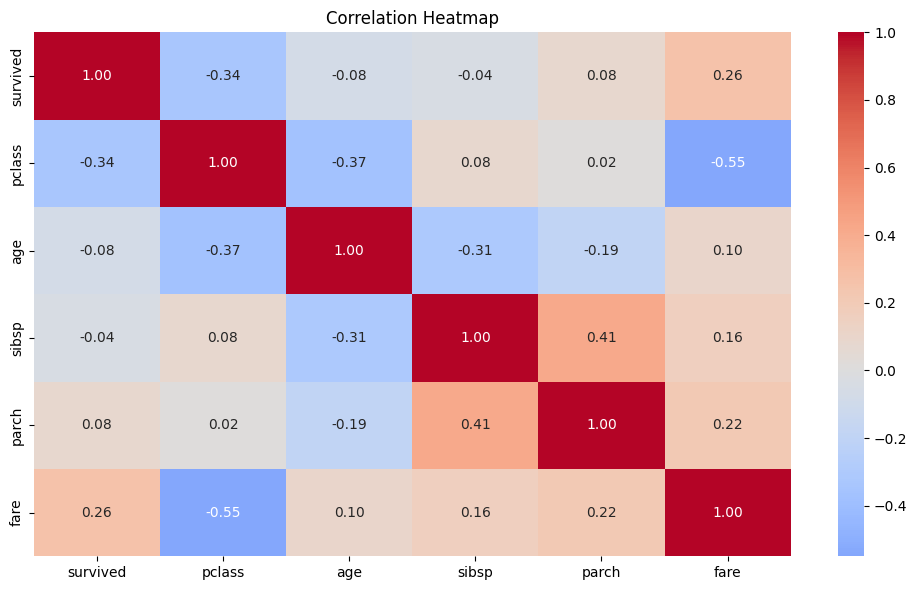

In [32]:
#correlation heatmap for numeric features
plt.figure(figsize=(10,6))

#compute correlation matrix for numeric features
corr_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(corr_matrix,
            annot=True,        # show numbers inside boxes
            fmt='.2f',         # 2 decimal places
            cmap='coolwarm',   # blue=negative, red=positive
            center=0)          # center colormap at 0
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/08_correlation_heatmap.png')
plt.show()